# **Filtro Wiener**


---



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz
from scipy import signal
from numpy.random import randn

## 1. Generación de la señal


In [ ]:
f=5 # hz
fs = 1e3 # 1khz

t = np.linspace(0,1,int(fs))
w = 2*np.pi*f

s = np.sin(w*t)
Ns = len(s)


### 1.1 Gráficas de la señal

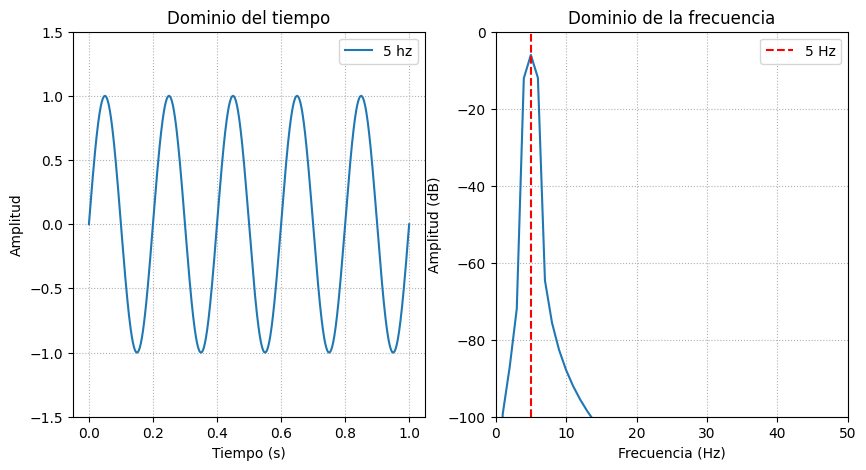

In [ ]:
# @title Gráfica en el dominio del tiempo
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Dominio del tiempo")
plt.plot(t,s, label=f"{f} hz")
plt.grid(ls=":")
plt.ylim(-1.5, 1.5)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.title("Dominio de la frecuencia")
plt.magnitude_spectrum(s,Fs=fs, scale="dB")
plt.grid(ls=":")
plt.xlim(0,50)
plt.ylim(-100,0)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud (dB)")
# marcar frecuencia de interés
plt.axvline(x=f, color='red', linestyle='--', label=f'{f} Hz')
plt.legend()

plt.show()

## 2. Generación del ruido aleatorio (blanco)

In [ ]:
n = np.random.normal(0, 0.2, Ns)

x = s + n

### 2.1 Gráfias de la señal con ruido

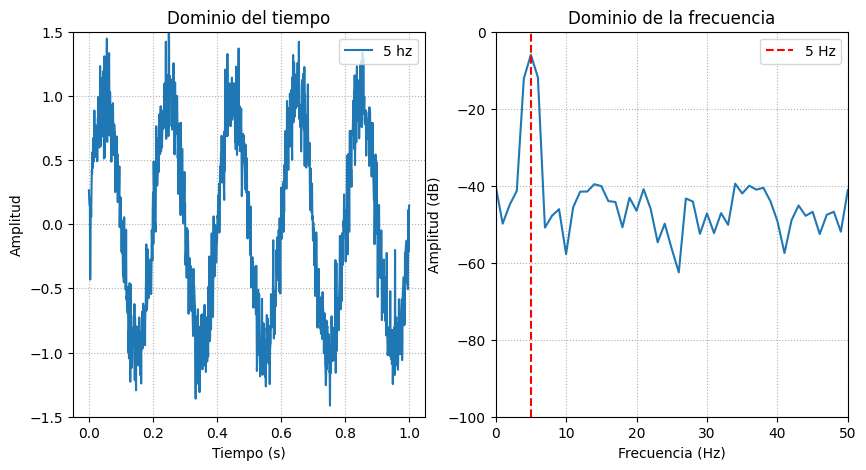

In [ ]:
# @title Gráfica en el dominio del tiempo
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Dominio del tiempo")
plt.plot(t,x, label=f"{f} hz")
plt.grid(ls=":")
plt.ylim(-1.5, 1.5)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.title("Dominio de la frecuencia")
plt.magnitude_spectrum(x,Fs=fs, scale="dB")
plt.grid(ls=":")
plt.xlim(0,50)
plt.ylim(-100,0)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud (dB)")
# marcar frecuencia de interés
plt.axvline(x=f, color='red', linestyle='--', label=f'{f} Hz')
plt.legend()

plt.show()

## 3. algoritmo de  wiener

In [ ]:
#Step 4: Autocorrelation of observed signal
rxx=np.correlate(x,x,mode='full')
#Step 5: Cross-correlation between desired and observed signal
rsx=np.correlate(s,x,mode='full')
#Step 6: Deciding the length of the filter
Nh=21
#Step 7: Trimming the autocorrelation and cross-correlation values
rxx1=rxx[Ns-1:Ns+Nh-1]
rsx1=rsx[Ns-1:Ns+Nh-1]
#Step 8: Obtaining the autocorrelation matrix
Rx=toeplitz(rxx1)
#Step 9: Inverse of the autocorrelation matrix
Rx1=np.linalg.inv(Rx)
#Step 10: Obtaining the filter coefficient
w1=np.matmul(Rx1,rsx1)

## 4. filtrado

In [ ]:
y=signal.lfilter(w1,1,x)


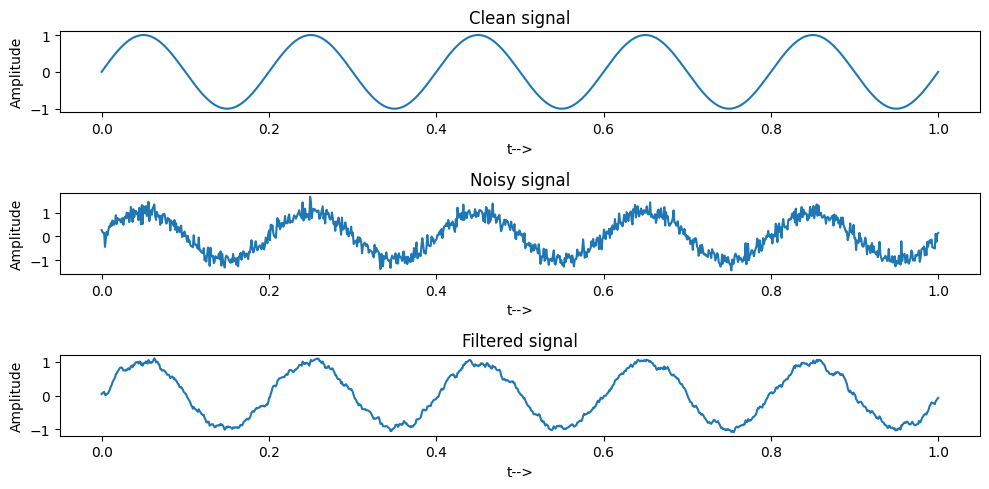

In [ ]:
# @title Gráficas del filtrado
plt.figure(figsize=(10,5))

plt.subplot(3,1,1)
plt.plot(t,s)
plt.xlabel('t-->')
plt.ylabel('Amplitude')
plt.title('Clean signal')

plt.subplot(3,1,2)
plt.plot(t,x)
plt.xlabel('t-->')
plt.ylabel('Amplitude')
plt.title('Noisy signal')

plt.subplot(3,1,3)
plt.plot(t,y)
plt.xlabel('t-->')
plt.ylabel('Amplitude')
plt.title('Filtered signal')
plt.tight_layout()

## 5. Filtro de Wiener de Scipy

y = wiener(x, mysize=5, noise=var_ruido)

$$mysize \simeq \frac{f_{s}}{f_{señal_máx}}$$

- fs = 1khz
- f = 5 hz

$$mysize \simeq \frac{1000}{50} = 20$$


In [ ]:
y=signal.wiener(x, mysize=41)


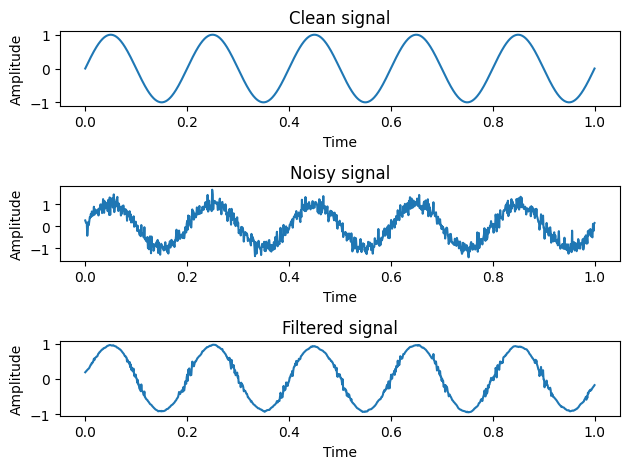

In [ ]:
# @title Gráficas de la señal a la salida del filtro wiener de scipy
#Step 4: Plotting the results
plt.subplot(3,1,1),plt.plot(t,s),
plt.xlabel('Time'),plt.ylabel('Amplitude'),plt.title('Clean signal')
plt.subplot(3,1,2),plt.plot(t,x),plt.xlabel('Time'),plt.ylabel('Amplitude'),
plt.title('Noisy signal'),plt.subplot(3,1,3),plt.plot(t,y)
plt.xlabel('Time'),plt.ylabel('Amplitude'),plt.title('Filtered signal')
plt.tight_layout()

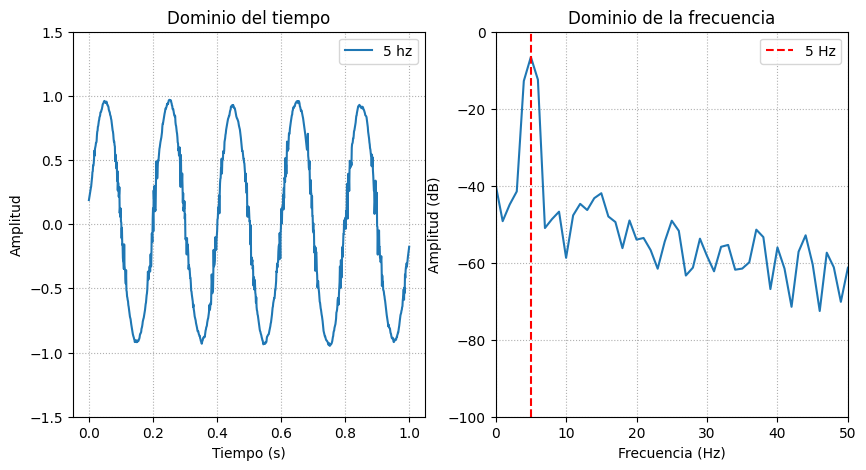

In [ ]:
# @title Gráfica en el dominio del tiempo
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Dominio del tiempo")
plt.plot(t,y, label=f"{f} hz")
plt.grid(ls=":")
plt.ylim(-1.5, 1.5)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend(loc="upper right")

plt.subplot(1,2,2)
plt.title("Dominio de la frecuencia")
plt.magnitude_spectrum(y,Fs=fs, scale="dB")
plt.grid(ls=":")
plt.xlim(0,50)
plt.ylim(-100,0)
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud (dB)")
# marcar frecuencia de interés
plt.axvline(x=f, color='red', linestyle='--', label=f'{f} Hz')
plt.legend()

plt.show()

# Filtro de Savitzky–Golay (SG)

Método de suavizado local que, a diferencia de un promedio móvil, ajusta un polinomio por mínimos cuadrados en una ventana deslizante y evalúa ese polinomio en el punto central.

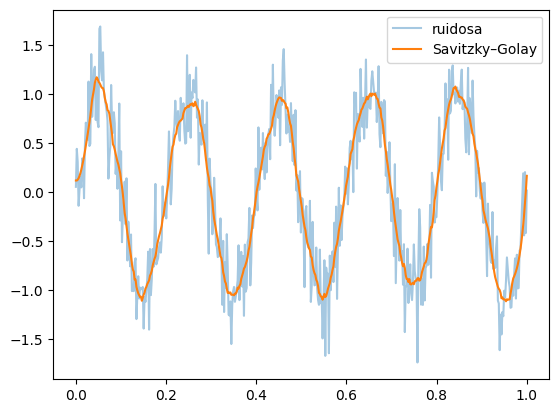

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

t = np.linspace(0, 1, 500)
y = np.sin(2*np.pi*5*t) + 0.3*np.random.randn(500)

y_sg = savgol_filter(y, window_length=31, polyorder=3)

plt.plot(t, y, alpha=0.4, label='ruidosa')
plt.plot(t, y_sg, label='Savitzky–Golay')
plt.legend()
plt.show()